## Import Libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Load Cars Dataset

In [24]:
car_data = pd.read_csv("cars.csv")
car_data.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350,165,4209,12,1972,US.
1,31.9,4,89,71,1925,14,1980,Europe.
2,17.0,8,302,140,3449,11,1971,US.
3,15.0,8,400,150,3761,10,1971,US.
4,30.5,4,98,63,2051,17,1978,US.


In [26]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           261 non-null    float64
 1    cylinders    261 non-null    int64  
 2    cubicinches  261 non-null    object 
 3    hp           261 non-null    int64  
 4    weightlbs    261 non-null    object 
 5    time-to-60   261 non-null    int64  
 6    year         261 non-null    int64  
 7    brand        261 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 16.4+ KB


In [28]:
car_data[' cubicinches'] = pd.to_numeric(car_data[' cubicinches'], errors='coerce')
car_data[' weightlbs'] = pd.to_numeric(car_data[' weightlbs'], errors='coerce')

In [30]:
car_data=car_data.drop(" brand",axis=1)

In [32]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           261 non-null    float64
 1    cylinders    261 non-null    int64  
 2    cubicinches  259 non-null    float64
 3    hp           261 non-null    int64  
 4    weightlbs    258 non-null    float64
 5    time-to-60   261 non-null    int64  
 6    year         261 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 14.4 KB


In [34]:
car_data.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
0,14.0,8,350.0,165,4209.0,12,1972
1,31.9,4,89.0,71,1925.0,14,1980
2,17.0,8,302.0,140,3449.0,11,1971
3,15.0,8,400.0,150,3761.0,10,1971
4,30.5,4,98.0,63,2051.0,17,1978


In [38]:
car_data["year_till_date"]=2026-car_data[" year"]

In [40]:
car_data=car_data.drop(" year",axis=1)

In [42]:
car_data.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year_till_date
0,14.0,8,350.0,165,4209.0,12,54
1,31.9,4,89.0,71,1925.0,14,46
2,17.0,8,302.0,140,3449.0,11,55
3,15.0,8,400.0,150,3761.0,10,55
4,30.5,4,98.0,63,2051.0,17,48


In [44]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             261 non-null    float64
 1    cylinders      261 non-null    int64  
 2    cubicinches    259 non-null    float64
 3    hp             261 non-null    int64  
 4    weightlbs      258 non-null    float64
 5    time-to-60     261 non-null    int64  
 6   year_till_date  261 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 14.4 KB


In [48]:
100*car_data.isnull().mean()

mpg               0.000000
 cylinders        0.000000
 cubicinches      0.766284
 hp               0.000000
 weightlbs        1.149425
 time-to-60       0.000000
year_till_date    0.000000
dtype: float64

In [50]:
car_data[" cubicinches"]=car_data[" cubicinches"].fillna(car_data[" cubicinches"].median())
car_data[" weightlbs"]=car_data[" weightlbs"].fillna(car_data[" weightlbs"].median())

In [52]:
100*car_data.isnull().mean()

mpg               0.0
 cylinders        0.0
 cubicinches      0.0
 hp               0.0
 weightlbs        0.0
 time-to-60       0.0
year_till_date    0.0
dtype: float64

In [56]:
scalar=StandardScaler()
car_data_scaled=scalar.fit_transform(car_data)

In [62]:
df=pd.DataFrame(car_data_scaled,columns=car_data.columns)

In [64]:
df.head(2)

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year_till_date
0,-1.171127,1.393053,1.374668,1.450681,1.41670,-1.221287,1.327539
1,1.121226,-0.919105,-1.026454,-0.874768,-1.27795,-0.532829,-0.875880


# Elbow Method

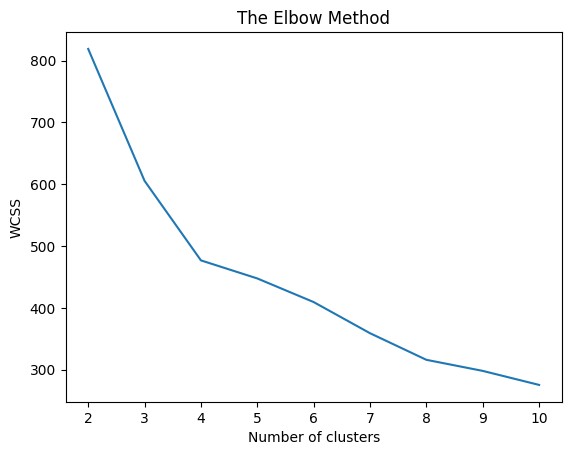

In [71]:
# Creating a funtion with KMeans to plot "The Elbow Method"
wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(2,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') ##WCSS stands for total within-cluster sum of square
plt.show()

In [75]:
for i in range(2,11):
    print(i,wcss[i-2])

2 818.7276688900427
3 605.405429703978
4 476.81772437994914
5 447.60246066693037
6 409.4129551090515
7 359.04088665942226
8 316.0338117823029
9 298.120220735423
10 275.4392583777491


In [81]:
optimal_k=3

In [83]:
kmeans = KMeans(n_clusters=optimal_k,random_state=0)
kmeans.fit(df)

KMeans(n_clusters=3, random_state=0)

In [87]:
kmeans.cluster_centers_

array([[ 1.22088676, -0.88205101, -0.84776764, -0.81260427, -0.89385156,
         0.468965  , -0.93944048],
       [-1.0415261 ,  1.37763847,  1.36865773,  1.34908656,  1.26136087,
        -1.01933969,  0.51594626],
       [-0.15846954, -0.31965654, -0.33818013, -0.3499848 , -0.23038559,
         0.36917784,  0.32018877]])

In [91]:
kmeans.labels_

array([1, 0, 1, 1, 0, 1, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 2, 0, 2,
       2, 1, 0, 0, 2, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2,
       1, 0, 1, 2, 0, 2, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 2,
       2, 0, 0, 1, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       2, 0, 0, 0, 1, 2, 0, 2, 1, 2, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1,
       2, 2, 1, 0, 0, 2, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 0, 2, 0, 2, 0,
       1, 1, 1, 1, 2, 1, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 1, 0, 0, 1, 2,
       0, 2, 2, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2,
       1, 1, 1, 0, 2, 0, 1, 1, 0, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 2, 2, 2, 2, 2, 1, 0, 2, 1, 2, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1,
       2, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0, 2, 1, 2, 0, 1, 2, 0, 2, 1, 2,
       1, 2, 1, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 2, 1, 0, 2, 2, 2],
      dtype=int32)

In [97]:
df["clusters"]=kmeans.labels_

In [107]:
car_data["clusters"]=kmeans.labels_

==================== mpg =========================


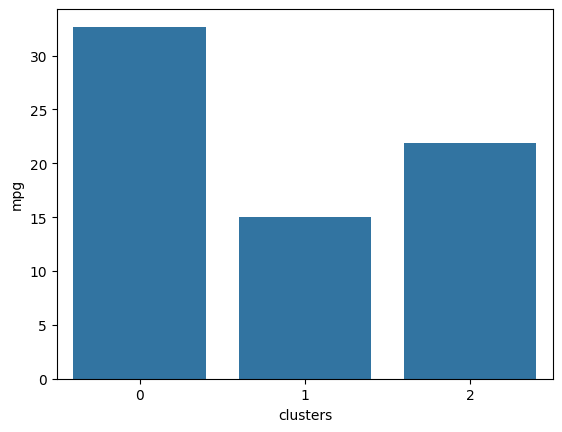

====================  cylinders =========================


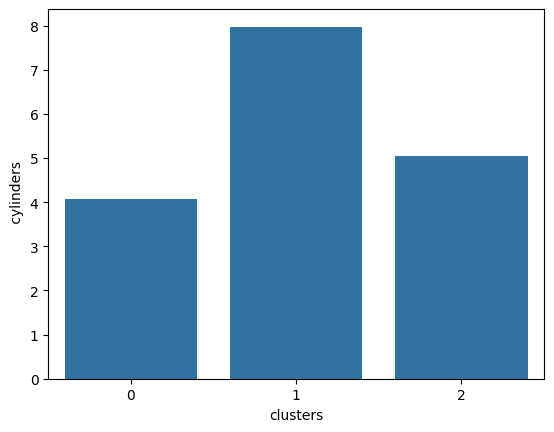

====================  cubicinches =========================


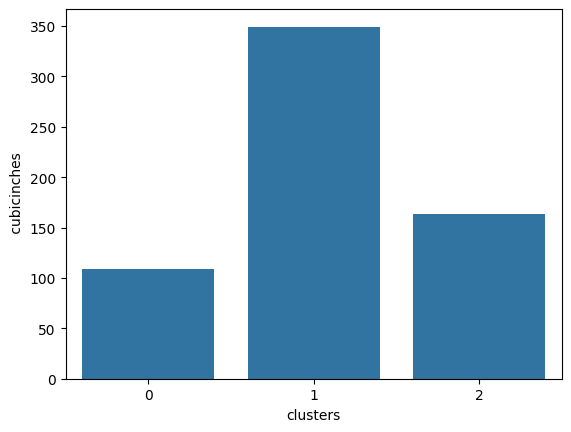

====================  hp =========================


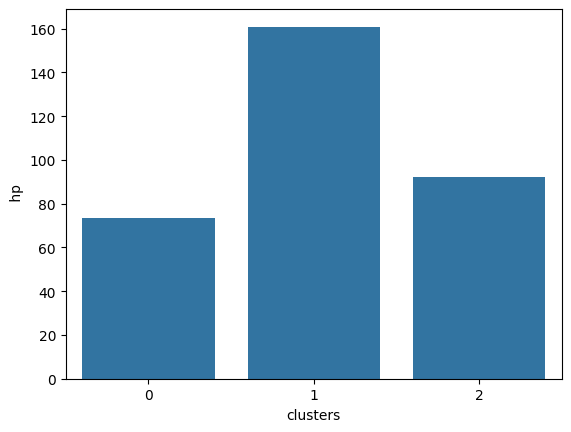

====================  weightlbs =========================


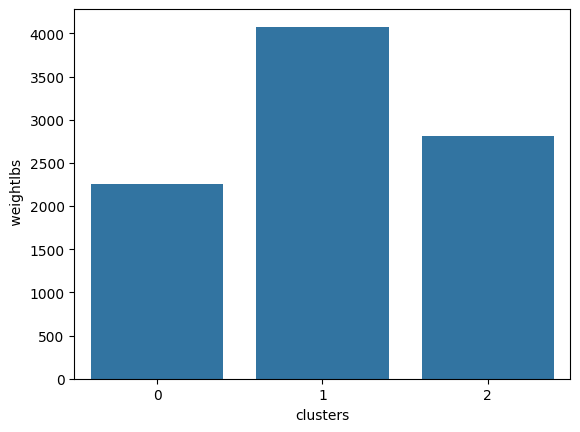

====================  time-to-60 =========================


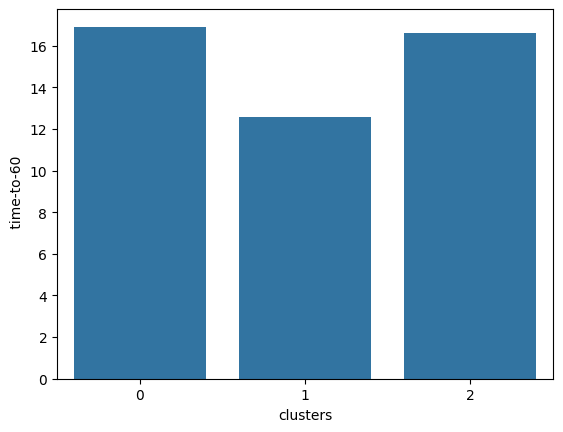

==================== year_till_date =========================


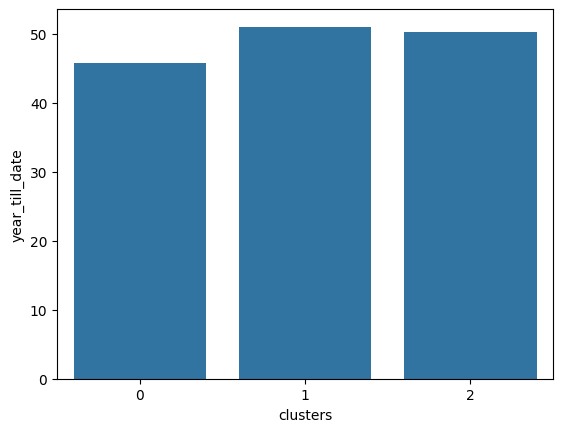

==================== clusters =========================


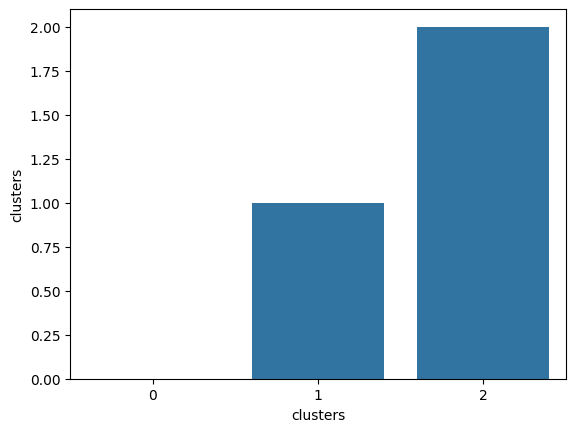

In [109]:
cols_list=list(car_data.columns)
for col in cols_list:
    print("====================",col,"=========================")
    seaborn.barplot(x=car_data["clusters"],y=car_data[col],errorbar=None)
    plt.show()

In [121]:
X=car_data.drop("clusters",axis=1).to_numpy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


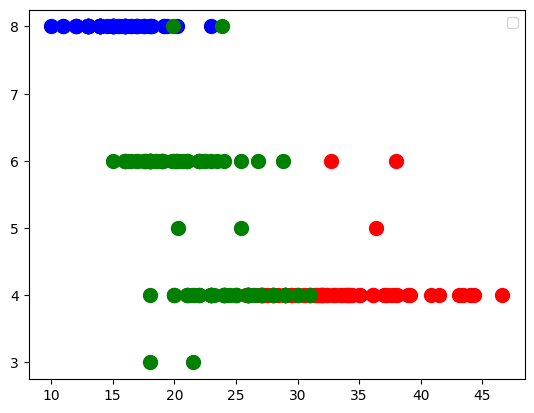

In [129]:
plt.scatter(X[kmeans.labels_ == 0, 0], X[kmeans.labels_ == 0,1],s=100,c='red')
plt.scatter(X[kmeans.labels_ == 1, 0], X[kmeans.labels_ == 1,1],s=100,c='blue')
plt.scatter(X[kmeans.labels_ == 2, 0], X[kmeans.labels_ == 2,1],s=100,c='green')
plt.legend()
plt.show()